In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df=pd.read_excel('Math_10th_filled.xlsx')

In [3]:
df.head()

,Year,Exercise_id,Exercise,Appeared,Chapter_Name
0,2025,Ex 1.1,1.1,1,Quadratic Equation
1,2025,Ex 1.2,1.2,1,Quadratic Equation
2,2025,Ex 1.3,1.3,1,Quadratic Equation
3,2025,Ex 2.1,2.1,1,Theory of Quadratic Equation
4,2025,Ex 2.2,2.2,0,Theory of Quadratic Equation


In [4]:
df['Chapter_Name'].unique()

array(['Quadratic Equation', 'Theory of Quadratic Equation', 'Variations',
       'Partial Fractions', 'Sets and Function', 'Basic Statistics',
       'Introduction to Trigonometry', 'Projection of side of Triangle',
       'Chords of Circle', 'Tangent to Circle', 'Chords and Arcs',
       'Angle in Segment of Cirle', 'Practical Geometry'], dtype=object)

In [5]:
df.isnull().sum()

Year            0
Exercise_id     0
Exercise        0
Appeared        0
Chapter_Name    0
dtype: int64

In [6]:
chapter_weight_map = {
    'Quadratic Equation':                0.1053,
    'Theory of Quadratic Equation':      0.1053,
    'Variations':                        0.0632,
    'Partial Fractions':                 0.0527,
    'Sets and Function':                 0.0737,
    'Basic Statistics':                  0.0632,
    'Introduction to Trigonometry':      0.1053,
    'Projection of side of Triangle':    0.0842,
    'Chords of Circle':                  0.0947,
    'Tangent to Circle':                 0.0420,
    'Chords and Arcs':                   0.0420,
    'Angle in Segment of Cirle':         0.0842,
    'Practical Geometry':                0.0842,
}

In [7]:
df['chapter_weight'] = df['Chapter_Name'].map(chapter_weight_map)

In [8]:
df = df.sort_values(['Exercise', 'Year']).reset_index(drop=True)

In [9]:
gaps = []
last_year_since_appeared = {}
for _, row in df.iterrows():
    exercise = row['Exercise']
    year = int(row['Year'])
    appeared = row['Appeared']
    if exercise not in last_year_since_appeared:
        gaps.append(-1)
    else:
        gaps.append(year - last_year_since_appeared[exercise])
    if appeared == 1:
        last_year_since_appeared[exercise] = year
df['Gaps'] = gaps

In [10]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    exercise = row['Exercise']
    year = row['Year']
    
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    exercise_data = df[df['Exercise'] == exercise]
    count = exercise_data[exercise_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [11]:
df['Appeared_last_year'] = df.groupby('Exercise')['Appeared'].shift(1).fillna(0).astype(int)

In [12]:
df['rolling_3'] = (df.groupby('Exercise')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

In [13]:
df.isnull().sum()

Year                  0
Exercise_id           0
Exercise              0
Appeared              0
Chapter_Name          0
chapter_weight        0
Gaps                  0
Frequency_Last_5      0
Appeared_last_year    0
rolling_3             0
dtype: int64

In [14]:
model_paper_topics = [
    'Ex 1.1', 'Ex 1.2', 'Ex 1.3',
    'Ex 2.1', 'Ex 2.2', 'Ex 2.3', 'Ex 2.4',
    'Ex 3.1', 'Ex 3.2',
    'Ex 4.1',
    'Ex 5.1', 'Ex 5.2', 'Ex 5.4', 'Ex 5.5',
    'Ex 6.3',
    'Ex 7.1', 'Ex 7.2', 'Ex 7.4', 'Ex 7.5',
    'Ex 8.1',
    'Ex 10.1',
    'Ex 13.1',
    'Th 9.1', 'Th 9.4',
    'Th 11.3',
    'Th 12.3(a)',
]

df['is_in_model_paper'] = df['Exercise_id'].apply(
    lambda x: 1 if x in model_paper_topics else 0
)

In [15]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [16]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['is_in_model_paper','Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [18]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

### Accuracy , Precision , Recall

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = pipe.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  83.33%
Precision:69.44%
Recall:100.00%


## Dummy Classifier

In [20]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.6212


"is_in_model_paper feature add karne se Recall 100% ho gaya — board ka model paper strong predictor hai actual exam topics ka."

### Accuarcy , Classification Report On Different Threshold

In [21]:
from sklearn.metrics import classification_report

y_prob_lr = pipe.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:83.33%

Threshold=0.5
              precision    recall  f1-score   support

           0       1.00      0.73      0.85        41
           1       0.69      1.00      0.82        25

    accuracy                           0.83        66
   macro avg       0.85      0.87      0.83        66
weighted avg       0.88      0.83      0.84        66

Accuracy:78.79%

Threshold=0.4
              precision    recall  f1-score   support

           0       1.00      0.66      0.79        41
           1       0.64      1.00      0.78        25

    accuracy                           0.79        66
   macro avg       0.82      0.83      0.79        66
weighted avg       0.86      0.79      0.79        66

Accuracy:72.73%

Threshold=0.3
              precision    recall  f1-score   support

           0       1.00      0.56      0.72        41
           1       0.58      1.00      0.74        25

    accuracy                           0.73        66
   macro avg       0.79      0.78  

### Prediction For 2026

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Exercise_id', 'Exercise', 'Chapter_Name', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Exercise_id', 'Exercise', 'Chapter_Name', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Exercise']
    years = df[
        (df['Exercise'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Maths_1stYear_Predictions_2026.xlsx', index=False)
print(final_predictions)

   Exercise_id Exercise                    Chapter_Name  Probability  \
0       Ex 1.1      1.1              Quadratic Equation     0.980330   
1       Ex 1.2      1.2              Quadratic Equation     0.980330   
2       Ex 1.3      1.3              Quadratic Equation     0.980330   
3       Ex 2.1      2.1    Theory of Quadratic Equation     0.980330   
4       Ex 2.3      2.3    Theory of Quadratic Equation     0.980330   
5       Ex 7.2      7.2    Introduction to Trigonometry     0.980330   
6       Ex 7.3      7.3    Introduction to Trigonometry     0.980330   
7       Ex 5.5      5.5               Sets and Function     0.972817   
8       Ex 5.4      5.4               Sets and Function     0.972817   
9       Ex 5.1      5.1               Sets and Function     0.972817   
10      Ex 6.3      6.3                Basic Statistics     0.969751   
11      Ex 3.3      3.3                      Variations     0.969751   
12      Ex 3.2      3.2                      Variations     0.96

In [23]:
# Sirf is_in_model_paper se predict karo
features_test = ['is_in_model_paper']
pipe_test = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_test.fit(X_train[features_test], y_train)
y_pred_test = pipe_test.predict(X_test[features_test])
print(f"Sirf model paper feature: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")

Sirf model paper feature: 0.7424
Recall: 0.6800


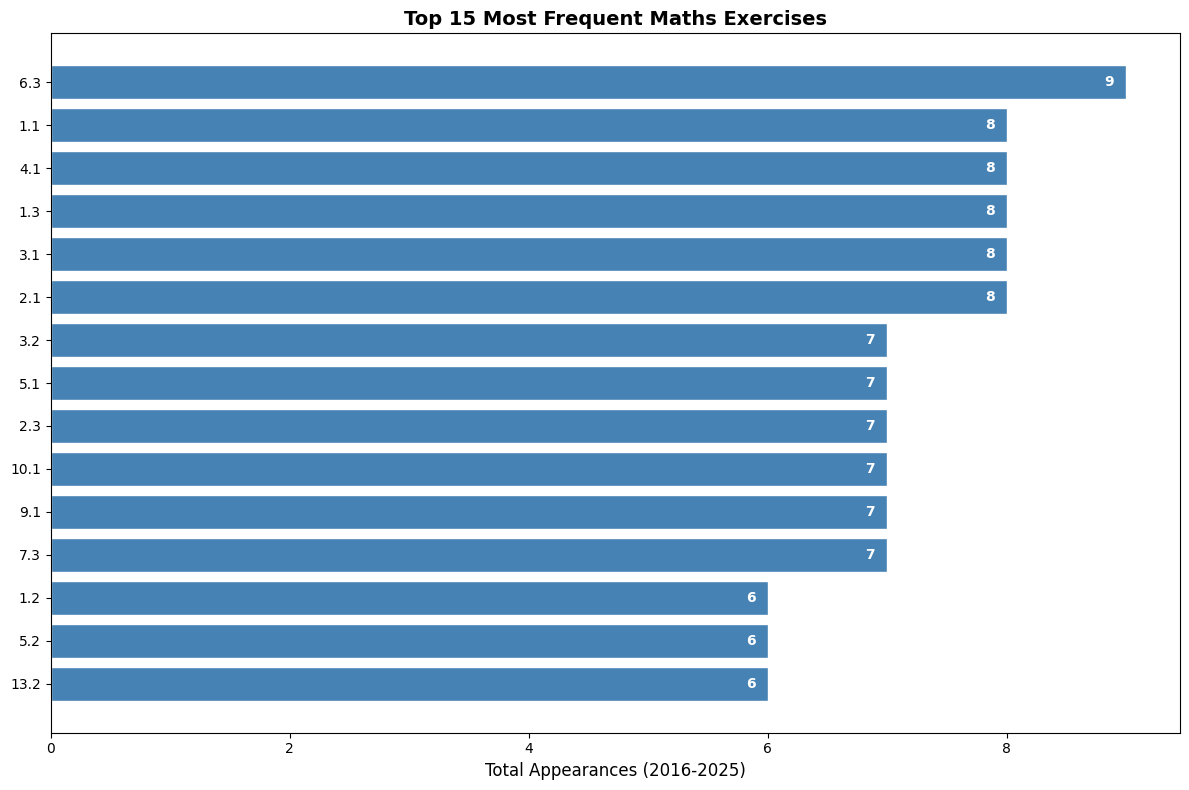

In [24]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Exercise')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Maths Exercises', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

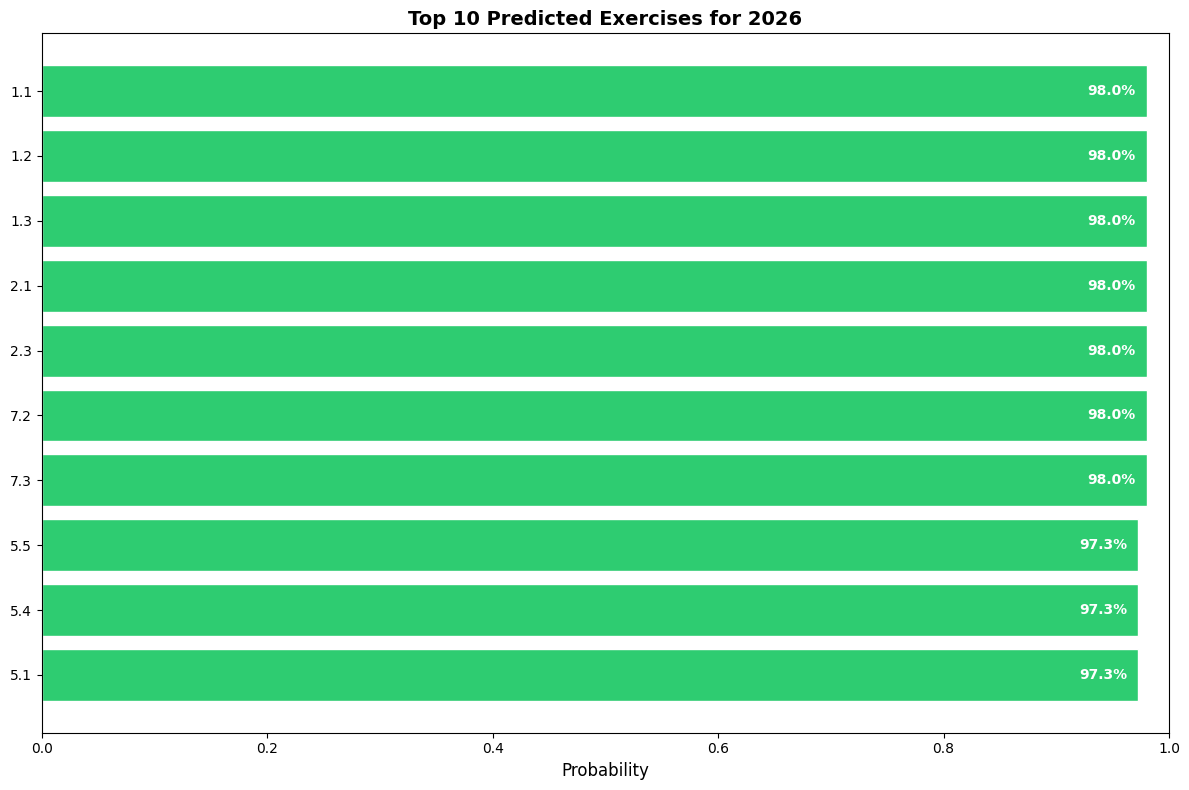

In [25]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Exercise'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Exercises for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()